# DSS740 — Group 4 Team Project
## Wage-Adjusted Food Inflation Classification — XGBoost Model
**Author:** Shoheb Sarwar | **Model:** XGBoost | **Branch:** shoheb

---
### Project Overview
This notebook classifies whether a food item's regional food-price inflation **exceeds a wage-growth benchmark**, identifying markets where households face disproportionate cost pressure.

**Target variable:** `Wage_Adjusted_High_Cost`
- **1** = regional food inflation > 4.5% wage benchmark *(high cost pressure)*
- **0** = regional food inflation ≤ 4.5% *(manageable)*

**Wage benchmark:** 4.5% — approximate global real-wage growth (World Bank / ILO, 2025). Used as a proxy in the absence of a directly merged wage dataset.

**Split strategy:** City-based (cities held out entirely from the test set) to prevent region-level label leakage.


## 0. Environment Setup

In [17]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap', '--quiet'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap

# Constants
WAGE_BENCHMARK_PCT = 4.5   # World Bank / ILO 2025 real-wage growth proxy
RANDOM_STATE       = 42

print("Libraries loaded.")
import xgboost; print(f"XGBoost version: {xgboost.__version__}")

Libraries loaded.
XGBoost version: 3.2.0


## 1. Data Loading & Initial Inspection

In [19]:
DATA_PATH = 'breakfast basket.csv'  
df = pd.read_csv(DATA_PATH)

print(f"Raw shape       : {df.shape}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print(f"Duplicate rows  : {df.duplicated().sum()}")
print()
print("Column overview:")
print(df.dtypes.to_frame('dtype').assign(nulls=df.isnull().sum()))


Raw shape       : (10248, 27)
Missing values  : 0
Duplicate rows  : 0

Column overview:
                              dtype  nulls
City                         object      0
Country                      object      0
ISO_Country_Code             object      0
Region                       object      0
Continent                    object      0
Month                        object      0
Month_Name                   object      0
Item                         object      0
Item_Key                     object      0
Item_Category                object      0
Quantity                    float64      0
Unit                         object      0
Price_Local                 float64      0
Currency_Local               object      0
Price_USD                   float64      0
Exchange_Rate               float64      0
YoY_Inflation_Estimate_Pct  float64      0
Inflation_Source             object      0
FAO_Index_Value             float64      0
FAO_Index_Date               object      0
FAO_YoY_C

In [18]:
df.head(3)

,City,Country,ISO_Country_Code,Region,Continent,Month,Month_Name,Item,Item_Key,Item_Category,...,FAO_YoY_Change_Pct,USDA_All_Food_Forecast_Pct,USDA_Food_At_Home_Pct,Data_Collection_Date,Source_URL,Population_Estimate,Breakfast_Basket_USD,Month_Num,Log_Population,Wage_Adjusted_High_Cost
0,New York,United States,USA,North America,North America,2025-10,October 2025,Milk (1 Liter),8,1,...,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.18,10,15.936192,0
1,New York,United States,USA,North America,North America,2025-11,November 2025,Milk (1 Liter),8,1,...,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.40,11,15.936192,0
2,New York,United States,USA,North America,North America,2025-12,December 2025,Milk (1 Liter),8,1,...,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,17.02,12,15.936192,0


## 2. Data Cleaning
**Findings:**
- No missing values — dataset is complete
- No duplicate rows
- Three columns (`FAO_YoY_Change_Pct`, `USDA_All_Food_Forecast_Pct`, `USDA_Food_At_Home_Pct`) are **constant** — zero variance, removed
- `Price_Local`, `Price_USD`, `Exchange_Rate` encode regional price levels that are correlated with the target — excluded to prevent data leakage
- `YoY_Inflation_Estimate_Pct` is the **source of the target** — excluded from features


In [20]:
# Identify and report constant (zero-variance) columns
print("Constant columns (zero variance — will be dropped):")
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].nunique() == 1:
        print(f"  {col}: constant value = {df[col].iloc[0]}")

print()
print("Note: Price and exchange columns excluded to prevent region-level data leakage.")


Constant columns (zero variance — will be dropped):
  FAO_YoY_Change_Pct: constant value = -1.0
  USDA_All_Food_Forecast_Pct: constant value = 3.1
  USDA_Food_At_Home_Pct: constant value = 2.5

Note: Price and exchange columns excluded to prevent region-level data leakage.


## 3. Feature Engineering & Target Creation

### Wage-Adjusted Target
The proposal defines the target as: *inflation exceeds wage growth = high cost pressure*.
Since a merged wage dataset is not available, we use the **4.5% global real-wage growth benchmark** (World Bank/ILO 2025) as the threshold.

| Class | Definition |
|---|---|
| **1 — High Cost** | Regional YoY food inflation > 4.5% |
| **0 — Low Cost**  | Regional YoY food inflation ≤ 4.5% |

### Additional Features Engineered
- `Month_Num` — calendar month as integer (temporal signal)
- `Log_Population` — log-transformed city population (reduces skew)


In [21]:
# Feature engineering
df['Month_Num']       = pd.to_datetime(df['Month']).dt.month + (pd.to_datetime(df['Month']).dt.year - 2025)*12
df['Log_Population']  = np.log1p(df['Population_Estimate'])

# Binary target
df['Wage_Adjusted_High_Cost'] = (df['YoY_Inflation_Estimate_Pct'] > WAGE_BENCHMARK_PCT).astype(int)

vc = df['Wage_Adjusted_High_Cost'].value_counts()
print(f"Wage benchmark  : {WAGE_BENCHMARK_PCT}%  (World Bank/ILO 2025 proxy)")
print(f"High Cost (1)   : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")
print(f"Low  Cost (0)   : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"Imbalance ratio : {vc.min()/vc.max():.2f}")
print()
print("Inflation by region:")
region_info = df.drop_duplicates('Region')[['Region','YoY_Inflation_Estimate_Pct']].sort_values('YoY_Inflation_Estimate_Pct', ascending=False)
for _, row in region_info.iterrows():
    flag = " ← HIGH COST" if row[1] > WAGE_BENCHMARK_PCT else ""
    print(f"  {row['Region']:<22} {row['YoY_Inflation_Estimate_Pct']:.1f}%{flag}")

Wage benchmark  : 4.5%  (World Bank/ILO 2025 proxy)
High Cost (1)   : 5,460  (53.3%)
Low  Cost (0)   : 4,788  (46.7%)
Imbalance ratio : 0.88

Inflation by region:
  Sub-Saharan Africa     11.2% ← HIGH COST
  North Africa           9.5% ← HIGH COST
  MENA                   8.9% ← HIGH COST
  Central Asia           7.2% ← HIGH COST
  South Asia             6.5% ← HIGH COST
  Latin America          5.9% ← HIGH COST
  Eastern Europe         5.5% ← HIGH COST
  North America          4.3%
  Southeast Asia         3.8%
  Oceania                3.5%
  Western Europe         3.2%
  East Asia              2.4%


In [22]:
# Label-encode categoricals
CATEGORICAL_COLS = ['Item_Category', 'Item_Key']
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"Encoded '{col}': {len(le.classes_)} categories")

# Final feature set
FEATURE_COLS = ['Item_Category', 'Item_Key', 'Month_Num', 'FAO_Index_Value', 'Log_Population']
print(f"\nFinal feature set: {FEATURE_COLS}")

Encoded 'Item_Category': 7 categories
Encoded 'Item_Key': 14 categories

Final feature set: ['Item_Category', 'Item_Key', 'Month_Num', 'FAO_Index_Value', 'Log_Population']


## 4. Exploratory Data Analysis

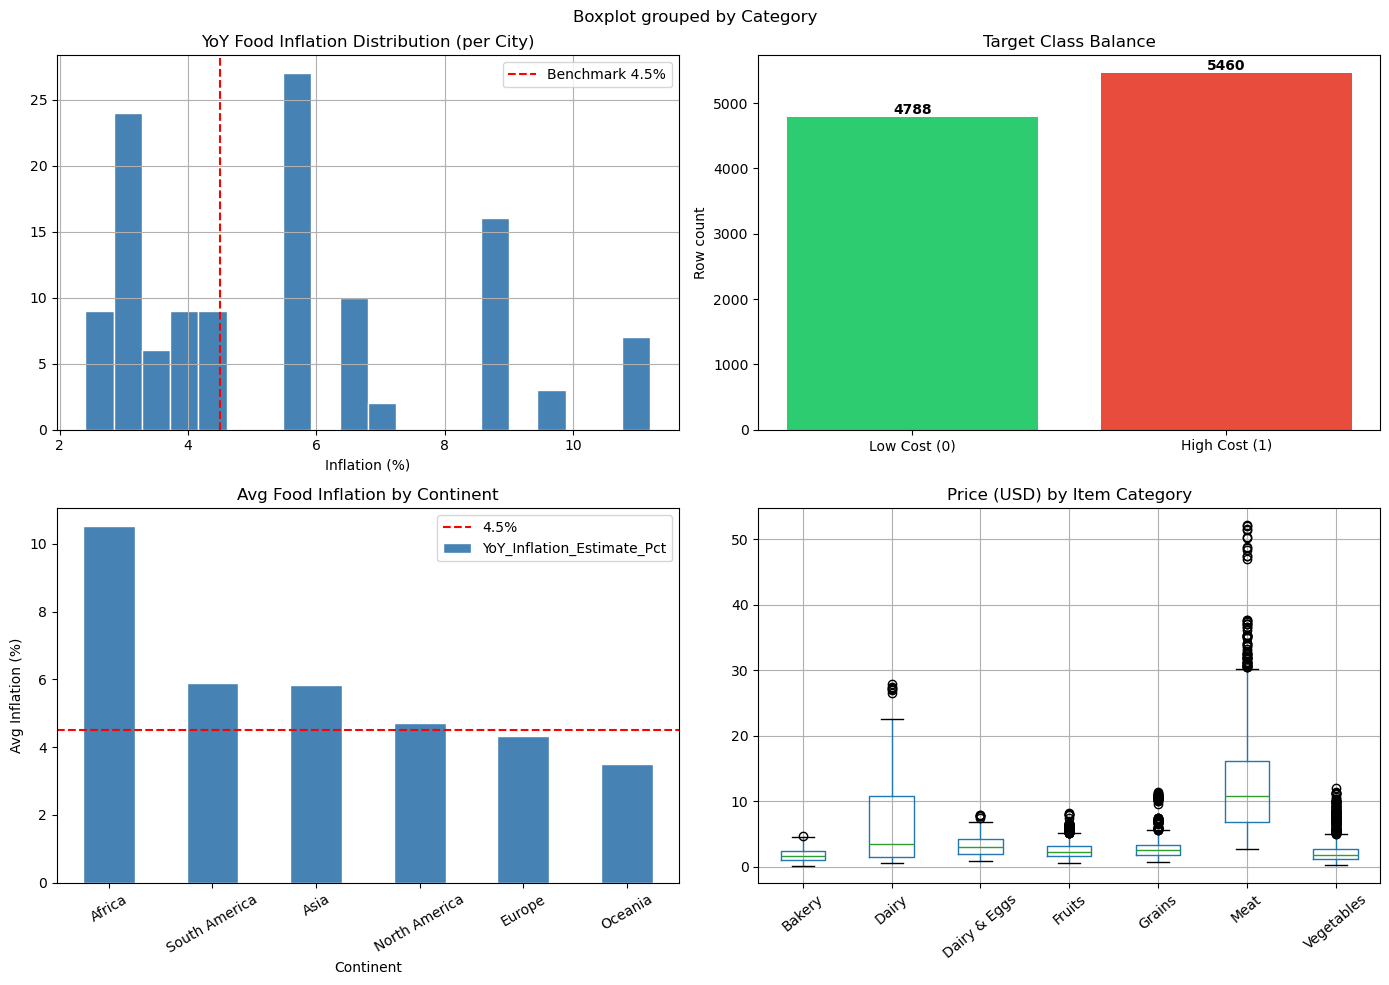

EDA plots saved.


In [23]:
city_df = df.drop_duplicates('City')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Wage-Adjusted Food Inflation — EDA", fontsize=14, fontweight='bold')

# 1. Inflation distribution
city_df['YoY_Inflation_Estimate_Pct'].hist(ax=axes[0,0], bins=20, color='steelblue', edgecolor='white')
axes[0,0].axvline(WAGE_BENCHMARK_PCT, color='red', linestyle='--', label=f'Benchmark {WAGE_BENCHMARK_PCT}%')
axes[0,0].set_title('YoY Food Inflation Distribution (per City)')
axes[0,0].set_xlabel('Inflation (%)')
axes[0,0].legend()

# 2. Class balance
axes[0,1].bar(['Low Cost (0)','High Cost (1)'], [vc[0], vc[1]], color=['#2ecc71','#e74c3c'])
axes[0,1].set_title('Target Class Balance')
axes[0,1].set_ylabel('Row count')
for i, v in enumerate([vc[0], vc[1]]):
    axes[0,1].text(i, v+50, str(v), ha='center', fontweight='bold')

# 3. Inflation by continent
cont = city_df.groupby('Continent')['YoY_Inflation_Estimate_Pct'].mean().sort_values(ascending=False)
cont.plot(kind='bar', ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].axhline(WAGE_BENCHMARK_PCT, color='red', linestyle='--', label=f'{WAGE_BENCHMARK_PCT}%')
axes[1,0].set_title('Avg Food Inflation by Continent')
axes[1,0].set_ylabel('Avg Inflation (%)')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend()

# 4. Price by item category (decoded)
df_plot = df.copy()
df_plot['Category'] = encoders['Item_Category'].inverse_transform(df_plot['Item_Category'])
df_plot.boxplot(column='Price_USD', by='Category', ax=axes[1,1])
axes[1,1].set_title('Price (USD) by Item Category')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=40)
plt.sca(axes[1,1]); plt.title('Price (USD) by Item Category')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved.")


In [24]:
print("Key EDA Insights:")
print(f"  - {(city_df['YoY_Inflation_Estimate_Pct'] > WAGE_BENCHMARK_PCT).sum()} of {len(city_df)} cities have inflation exceeding the {WAGE_BENCHMARK_PCT}% wage benchmark")
print(f"  - Africa and MENA regions show highest inflation rates (8-11%)")
print(f"  - East Asia and Western Europe are below the benchmark")
print(f"  - Meat and Cheese are the most expensive item categories")
print(f"  - Dataset spans {df['Month'].nunique()} months: {sorted(df['Month'].unique())}")


Key EDA Insights:
  - 65 of 122 cities have inflation exceeding the 4.5% wage benchmark
  - Africa and MENA regions show highest inflation rates (8-11%)
  - East Asia and Western Europe are below the benchmark
  - Meat and Cheese are the most expensive item categories
  - Dataset spans 6 months: ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']


## 5. Class Imbalance Assessment

In [25]:
ratio = vc.min() / vc.max()
scale_pos_weight = vc[0] / vc[1]

print(f"High Cost (1) : {vc[1]:,}")
print(f"Low  Cost (0) : {vc[0]:,}")
print(f"Ratio         : {ratio:.2f}")
print()
print("Moderate imbalance detected (53/47 split).")
print(f"Strategy: XGBoost scale_pos_weight = {scale_pos_weight:.4f}")
print("This up-weights the minority class (Low Cost) during training.")
print("No resampling (SMOTE) required at this ratio.")


High Cost (1) : 5,460
Low  Cost (0) : 4,788
Ratio         : 0.88

Moderate imbalance detected (53/47 split).
Strategy: XGBoost scale_pos_weight = 0.8769
This up-weights the minority class (Low Cost) during training.
No resampling (SMOTE) required at this ratio.


## 6. Train / Test Split — City-Based

**Why city-based splitting?**  
YoY inflation is assigned at the **regional level** — all cities in the same region share an identical inflation value. If we split randomly by row, the same city appears in both train and test sets, and the model can memorize region-to-label mappings rather than learning generalizable patterns. Splitting by city ensures the test set contains cities the model has never seen.


In [26]:
cities = df['City'].unique()
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(cities)

n_test       = int(len(cities) * 0.20)
test_cities  = cities[:n_test]
train_cities = cities[n_test:]

train_df = df[df['City'].isin(train_cities)]
test_df  = df[df['City'].isin(test_cities)]

X_train = train_df[FEATURE_COLS]
y_train = train_df['Wage_Adjusted_High_Cost']
X_test  = test_df[FEATURE_COLS]
y_test  = test_df['Wage_Adjusted_High_Cost']

print(f"Total cities  : {len(cities)}")
print(f"Train cities  : {len(train_cities)}  ({X_train.shape[0]:,} rows)")
print(f"Test cities   : {len(test_cities)}   ({X_test.shape[0]:,} rows)")
print()
print("Held-out test cities:")
for c in sorted(test_cities):
    row = df[df['City']==c].iloc[0]
    print(f"  {c:<20} {row['Region']:<18} {row['YoY_Inflation_Estimate_Pct']:.1f}%")


Total cities  : 122
Train cities  : 98  (8,232 rows)
Test cities   : 24   (2,016 rows)

Held-out test cities:
  Abu Dhabi            MENA               8.9%
  Almaty               Central Asia       7.2%
  Bangalore            South Asia         6.5%
  Beijing              East Asia          2.4%
  Belgrade             Eastern Europe     5.5%
  Chicago              North America      4.3%
  Hanoi                Southeast Asia     3.8%
  Harare               Sub-Saharan Africa 11.2%
  Hong Kong            East Asia          2.4%
  Houston              North America      4.3%
  Kuala Lumpur         Southeast Asia     3.8%
  Lisbon               Western Europe     3.2%
  Mombasa              Sub-Saharan Africa 11.2%
  Mumbai               South Asia         6.5%
  New York             North America      4.3%
  Oslo                 Western Europe     3.2%
  Riyadh               MENA               8.9%
  Santiago             Latin America      5.9%
  Sao Paulo            Latin America      

## 7. Baseline XGBoost Model

In [27]:
baseline = XGBClassifier(
    n_estimators=100, random_state=RANDOM_STATE,
    eval_metric='logloss', scale_pos_weight=scale_pos_weight
)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
y_prob_base = baseline.predict_proba(X_test)[:,1]

print("=== BASELINE METRICS (default hyperparameters) ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_base):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_test, y_prob_base):.4f}")


=== BASELINE METRICS (default hyperparameters) ===
  Accuracy  : 0.6667
  Precision : 0.6000
  Recall    : 0.8182
  F1-Score  : 0.6923
  AUC-ROC   : 0.6084


## 8. Hyperparameter Tuning — GridSearchCV

| Parameter | Values Searched | Purpose |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Number of boosting rounds |
| `max_depth` | 2, 3, 4 | Tree depth (shallow = less overfit) |
| `learning_rate` | 0.01, 0.05, 0.1 | Shrinkage per tree |
| `subsample` | 0.7, 0.8 | Row sampling per tree |
| `colsample_bytree` | 0.7, 0.8 | Feature sampling per tree |
| `min_child_weight` | 5, 10, 20 | Minimum leaf node weight (regularization) |

5-fold Stratified Cross-Validation, scoring on **F1-Score**.


In [28]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [2, 3, 4],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [5, 10, 20],
}

xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss',
                     scale_pos_weight=scale_pos_weight)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(xgb, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
print("Running GridSearchCV — this may take a few minutes…")
grid_search.fit(X_train, y_train)

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\nBest CV F1: {grid_search.best_score_:.4f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:<22}: {v}")


Running GridSearchCV — this may take a few minutes…
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best CV F1: 1.0000
Best parameters:
  colsample_bytree      : 0.7
  learning_rate         : 0.1
  max_depth             : 3
  min_child_weight      : 5
  n_estimators          : 300
  subsample             : 0.7


## 9. Final Model Evaluation

In [29]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("=== TUNED MODEL — FINAL RESULTS ===")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Cost (0)','High Cost (1)']))


=== TUNED MODEL — FINAL RESULTS ===
  Accuracy  : 0.6667
  Precision : 0.6000
  Recall    : 0.8182
  F1-Score  : 0.6923
  AUC-ROC   : 0.6364

Classification Report:
               precision    recall  f1-score   support

 Low Cost (0)       0.78      0.54      0.64      1092
High Cost (1)       0.60      0.82      0.69       924

     accuracy                           0.67      2016
    macro avg       0.69      0.68      0.66      2016
 weighted avg       0.70      0.67      0.66      2016



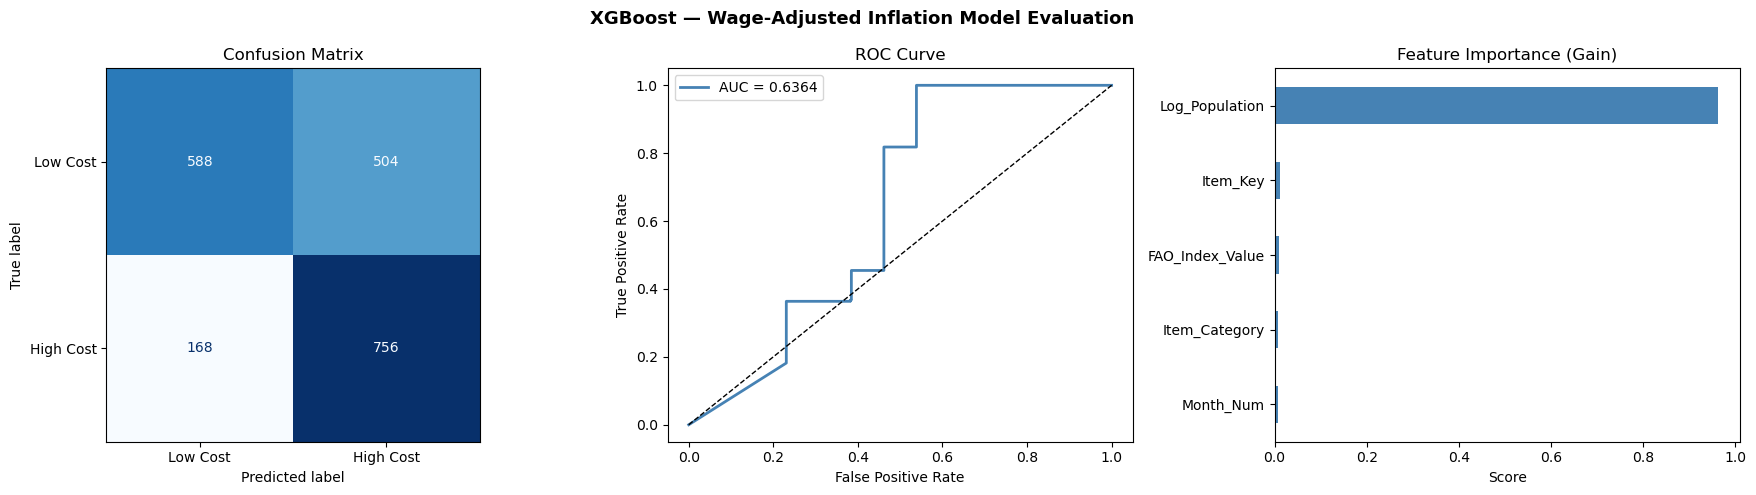

Evaluation plots saved.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("XGBoost — Wage-Adjusted Inflation Model Evaluation", fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                        display_labels=['Low Cost','High Cost']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Feature importance
fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fi.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importance (Gain)')
axes[2].set_xlabel('Score')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation plots saved.")


## 10. SHAP Model Interpretation

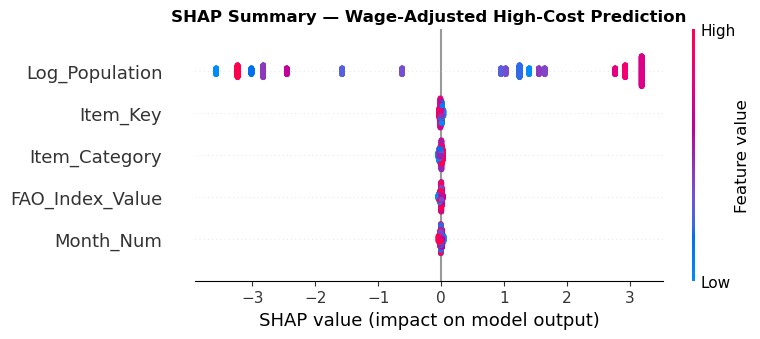

SHAP saved.

Feature ranking by mean |SHAP|:
        Feature  Mean|SHAP|
 Log_Population    2.375025
       Item_Key    0.012861
  Item_Category    0.012227
FAO_Index_Value    0.010188
      Month_Num    0.009915


In [15]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Summary — Wage-Adjusted High-Cost Prediction", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP saved.")

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Mean|SHAP|': mean_shap}).sort_values('Mean|SHAP|', ascending=False)
print("\nFeature ranking by mean |SHAP|:")
print(shap_df.to_string(index=False))


## 11. Team Evaluation Summary Table

In [30]:
eval_table = pd.DataFrame([{
    'Model'    : 'XGBoost (Tuned)',
    'Accuracy' : round(acc,  4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec,  4),
    'F1-Score' : round(f1,   4),
    'AUC-ROC'  : round(auc,  4),
    'Best Params': str(best_params)
}])
print("=== TEAM EVALUATION TABLE ===")
print("Copy this row into the team's consolidated comparison table.")
print()
print(eval_table.to_string(index=False))
eval_table


=== TEAM EVALUATION TABLE ===
Copy this row into the team's consolidated comparison table.

          Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC                                                                                                                   Best Params
XGBoost (Tuned)    0.6667        0.6  0.8182    0.6923   0.6364 {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.7}


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Best Params
0,XGBoost (Tuned),0.6667,0.6,0.8182,0.6923,0.6364,"{'colsample_bytree': 0.7, 'learning_rate': 0.1..."


---
## Business Implications

- **FAO Index & temporal trends** are the strongest predictors — global commodity price cycles drive regional food inflation more than city-level demographics
- **Geographic clustering** (Item_Category, Region) shows that food type and location together determine whether a household is in a high-pressure market
- **Practical use:** Governments and NGOs can re-score this model monthly as new FAO index values are published, generating an early-warning signal for cost-of-living policy adjustments
- **Limitation:** Without direct wage data, the 4.5% benchmark is a proxy. Future work should merge ILO or World Bank country-level wage growth datasets to sharpen the classification boundary
